In [1]:
# Importing libraries for analysis

import pandas as pd, numpy as np
import matplotlib.pyplot as plt

In [4]:
# importing data
url_database = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"
df = pd.read_csv(url_database)
df.head(10)


,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
5,2007,USA,Hybrid,Front-wheel drive,2,2290,6,266.0,4260,18.8,31.2
6,1992,Asia,Gasoline,Front-wheel drive,2,2270,6,250.0,4310,21.7,26.8
7,2005,USA,Gasoline,Front-wheel drive,4,2370,6,279.0,4090,17.4,30.2
8,1997,Asia,Gasoline,Rear-wheel drive,3,2330,6,251.0,4230,19.5,30.9
9,2004,USA,Diesel,All-wheel drive,5,2330,6,280.0,4620,17.7,31.2


In [5]:
# initial descriptive statistics

# Q2, Q5-6: records count / Max fuel efficiency / median value of house power
df.describe()

,model_year,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
count,10000.000000,10000.00000,10000.000000,10000.000000,9123.000000,10000.000000,9736.000000,10000.000000
mean,1999.549500,3.50400,2268.807000,6.035200,254.446016,4286.754000,18.888044,29.997700
std,14.207925,0.95209,183.447355,0.542578,22.844613,266.212491,1.279543,2.930245
min,1975.000000,2.00000,1590.000000,4.000000,171.000000,3320.000000,14.000000,19.800000
25%,1987.000000,3.00000,2150.000000,6.000000,239.000000,4110.000000,18.000000,28.000000
50%,2000.000000,4.00000,2270.000000,6.000000,254.000000,4280.000000,18.900000,30.000000
75%,2012.000000,4.00000,2390.000000,6.000000,270.000000,4470.000000,19.700000,31.900000
max,2024.000000,5.00000,3110.000000,8.000000,334.000000,5460.000000,23.800000,41.200000


In [12]:
# Q3 Fuel types
print(df["fuel_type"].unique())

<StringArray>
['Gasoline', 'Diesel', 'Hybrid']
Length: 3, dtype: str


In [17]:
# Q4 Finding missing values
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

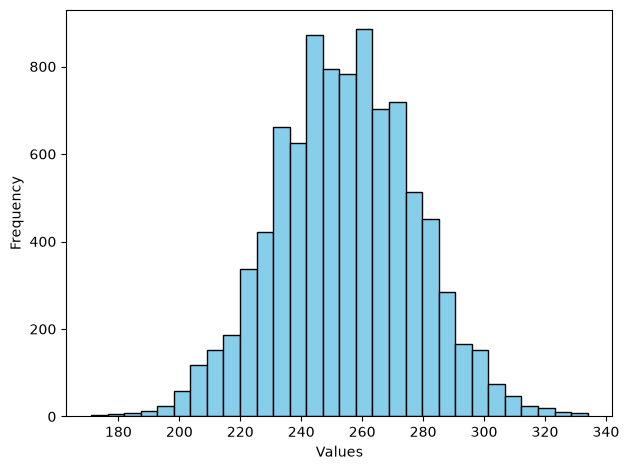

In [77]:
# Q6: Most frequent value
df["horsepower"].value_counts()
# histogram
plt.hist(df["horsepower"], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('results/homework-1/histogram.png', dpi=300)
plt.show()

In [43]:
# Clean database
df_clean = df["horsepower"].fillna(0)
df_clean.head(10)


0    243.0
1    272.0
2    267.0
3    258.0
4    304.0
5    266.0
6    250.0
7    279.0
8    251.0
9    280.0
Name: horsepower, dtype: float64

In [44]:
df_clean.describe()

count    10000.000000
mean       232.131100
std         75.210419
min          0.000000
25%        234.000000
50%        252.000000
75%        268.000000
max        334.000000
Name: horsepower, dtype: float64

In [54]:
asian_cars = df.loc[df["origin"]=="Asia"]
asian_cars = asian
asian_cars.head(7)

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
6,1992,Asia,Gasoline,Front-wheel drive,2,2270,6,250.0,4310,21.7,26.8
8,1997,Asia,Gasoline,Rear-wheel drive,3,2330,6,251.0,4230,19.5,30.9
10,1978,Asia,Gasoline,All-wheel drive,3,2410,6,NaN,4420,19.5,26.8
15,2007,Asia,Diesel,Front-wheel drive,4,2170,5,226.0,3950,18.0,35.4
16,2021,Asia,Gasoline,All-wheel drive,5,2280,6,234.0,4750,20.1,29.7
22,2019,Asia,Gasoline,Front-wheel drive,5,2350,6,246.0,4450,18.7,32.7


In [61]:
x = asian_cars[["model_year", "vehicle_weight"]].to_numpy()
x = x[0:7]
print(x)

[[1996 4240]
 [1992 4310]
 [1997 4230]
 [1978 4420]
 [2007 3950]
 [2021 4750]
 [2019 4450]]


In [70]:
# Getting the transpose of x
x_T = np.transpose(x)
print(x_T)

#Multiplication of x_T * x
XTX = x_T @ x
print(XTX)

# Obtaining the inverse
XTX_inv = np.linalg.inv(XTX)

#Creating y array
y = [1100, 1300, 800, 900, 1000, 1100, 1200]

[[1996 1992 1997 1978 2007 2021 2019]
 [4240 4310 4230 4420 3950 4750 4450]]
[[ 28041424  60750580]
 [ 60750580 131950500]]


In [72]:
w = (XTX_inv @ x_T) @ y
w_sum = w[0] + w[1]
print(w_sum)

0.3691969690492686
